## Credits & Attribution

**Original Source:** David Dale (https://daviddale.ru/) — NLP researcher at Meta FAIR, contributor to NLLB.

Original tutorial: Fine-tuning NLLB-200 for Tyvan-Russian translation.

This notebook has been substantially modified for French-Adja translation:
- Replaced dataset loading for Adja-French parallel corpora
- Adjusted tokenizer and language code configuration for Adja
- Modified training parameters for low-resource setting
- Adapted evaluation pipeline for our experiment protocol

---

In this notebook, I show how to fine-tune a NLLB-200 machine translation model for a new language.

The new language will be [Tyvan](https://en.wikipedia.org/wiki/Tuvan_language), and I will use a Tyvan-Russian parallel corpus as the training data.

I am running this notebook on Google Colab with a T4 GPU that has 15Gb of memory. If you run it elsewhere, you may want to adjust the batch size, so that there are no OOM errors, but the GPU is well utilized.

# 0. Preliminaries

I run this notebook in Google Colab (which is ephemeral), and to read the dataset and to write the resulting model I use Google Drive, which I mount in the cell below.

In [ ]:
# we do not do this as we want to upload our dataset from our local stuff

# from google.colab import drive
# import os
# if not os.path.exists('/gd'):
#     drive.mount('/gd')

In [ ]:
# Upload manually
from google.colab import files
import pandas as pd

# uploaded = files.upload()  # then you can read your file from /content/
# 10_000_for_data_paper_LREC
trans_df = pd.read_csv('/content/simple-dataset.csv')
print(trans_df.head())


   ID                 French                Translation  original_id  \
0   1        je mange du riz              ŋu ɖuɖuɔ mɔlu            1   
1   2       je mange du pain             ŋu ɖuɖuɔ kpɔnɔ            2   
2   3    je mange du poisson             ŋu ɖuɖuɔ kpavi            3   
3   4  je mange de la viande              ŋu ɖuɖuɔ elan            4   
4   5    je mange des fruits  ŋu ɖuɖuɔ acikusɛnsɛn ɖewo            5   

    dataset_source  
0  phrases_simples  
1  phrases_simples  
2  phrases_simples  
3  phrases_simples  
4  phrases_simples  


Installing dependencies:
* `transformers`, as a neural network framework
* `sentencepiece`, a backend for my tokenizer (the algorithm for converting a text into symbols from the model's vocabulary)
* `sacremoses`, a package required for text preprocessing with which NLLB models were pretrained.
* `sacrebleu`, a package for evaluating translation models

In [ ]:
import locale
def gpe(x=None):
    return "UTF-8"
locale.getpreferredencoding = gpe

In [ ]:
!pip install sentencepiece transformers==4.33 datasets sacremoses sacrebleu  -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 30.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based project

# 1. Exploring the data

In this section, I try to understand what is the training data that I have, and how suitable it is for fine-tuning a NLLB model.

In [ ]:
import pandas as pd

In [ ]:

# trans_df = pd.read_csv('/gd/MyDrive/datasets/nlp/tyvan/rus_tyv_parallel_50k.tsv', sep="\t")
# print(trans_df.shape)
# print(trans_df.columns)

trans_df = pd.read_csv('/content/simple-dataset.csv')  # Update with correct path
print(trans_df.shape)
print(trans_df.columns)



(4251, 5)
Index(['ID', 'French', 'Translation', 'original_id', 'dataset_source'], dtype='object')


In [ ]:
pd.options.display.max_colwidth = 100

In [ ]:
trans_df.sample(10)

,ID,French,Translation,original_id,dataset_source
2855,887,elle n'apporte pas les fruits,e hwɛnkɔ acikusɛnsɛn lɔwo vɛ go,887,partie2
1674,1675,Est-ce que vous buvez de l'eau?,mi nu nɔ eshi a?,1675,phrases_simples
1141,1142,elles ont donné le livre wo na,wemalɔ vayi,1142,phrases_simples
339,340,elles prennent le pain wo,sɔsɔ kpɔnɔ/wo xɔxɔ kpɔnɔ,340,phrases_simples
1662,1663,Est-ce que il boit du café?,e nu nɔ kafɛ a?,1663,phrases_simples
3422,1454,il va aimer le poisson,kpavi lɔ a jɔji n‘i,1454,partie2
1256,1257,ils vont boire du lait wo jiji,ɔ a nu lɛ,1257,phrases_simples
1225,1226,je vais boire de l'eau,ŋu jiji ɔ a nu eshi,1226,phrases_simples
3318,1350,tu as apporté le livre,e hɛn wema lɔ vɛ,1350,partie2
3480,1512,nous allons acheter du riz,mi a xlwe mɔlu,1512,partie2


In [ ]:
trans_df.isnull().sum()

,0
ID,0
French,0
Translation,0
original_id,0
dataset_source,0


In [ ]:
# trans_df.split.value_counts()

In [ ]:
# df_train = trans_df[trans_df.split=='train'].copy() # 49000 items
# df_dev = trans_df[trans_df.split=='dev'].copy()     # 500 items
# df_test = trans_df[trans_df.split=='test'].copy()   # 500 items

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(trans_df, test_size=0.2, random_state=42)

# Then split temp into 50% dev, 50% test → each will be 10% of total
dev_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)}, Dev size: {len(dev_df)}, Test size: {len(test_df)}")



Train size: 3400, Dev size: 425, Test size: 426


# 2. How well does the data fit into a NLLB tokenizer?

In [ ]:
from transformers import NllbTokenizer
from tqdm.auto import tqdm, trange

In [ ]:
tokenizer = NllbTokenizer.from_pretrained('facebook/nllb-200-distilled-600M')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

In [ ]:
import re

def word_tokenize(text):
    # a very naive word tokenizer for languages with English-like orthography
    return re.findall('(\w+|[^\w\s])', text)

<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-1495687817.py:5: SyntaxWarning: invalid escape sequence '\w'
  return re.findall('(\w+|[^\w\s])', text)


In [ ]:
# smpl = df_train.sample(10000, random_state=1)
smpl = train_df.sample(min(500, len(train_df)), random_state=1)  # sample 500 examples if possible


# smpl['rus_toks'] = smpl.ru.apply(tokenizer.tokenize)
# smpl['tyv_toks'] = smpl.tyv.apply(tokenizer.tokenize)

# smpl['rus_words'] = smpl.ru.apply(word_tokenize)
# smpl['tyv_words'] = smpl.tyv.apply(word_tokenize)

smpl['french_toks'] = smpl.French.apply(tokenizer.tokenize)
smpl['adja_toks'] = smpl.Translation.apply(tokenizer.tokenize)
smpl['french_words'] = smpl.French.apply(word_tokenize)
smpl['adja_words'] = smpl.Translation.apply(word_tokenize)


In [ ]:
# smpl.sample(5)[['tyv', 'tyv_words', 'tyv_toks', 'ru', 'rus_words', 'rus_toks']]
smpl.sample(5)[['Translation', 'adja_words', 'adja_toks', 'French', 'french_words', 'french_toks']]


,Translation,adja_words,adja_toks,French,french_words,french_toks
4200,mi e takɔshi ɔ?,"[mi, e, takɔshi, ɔ, ?]","[▁mi, ▁e, ▁tak, ɔ, shi, ▁ɔ, ?]",Qui est-ce que tu laisses?,"[Qui, est, -, ce, que, tu, laisses, ?]","[▁Qui, ▁est, -, ce, ▁que, ▁tu, ▁laiss, es, ?]"
4100,e xokɔ nuxu koɖo anyi ‘xlɔ a?,"[e, xokɔ, nuxu, koɖo, anyi, ‘, xlɔ, a, ?]","[▁e, ▁x, ok, ɔ, ▁nu, xu, ▁ko, ɖo, ▁anyi, ▁, ‘, xlɔ, ▁a, ?]",Est-ce que elle parle avec mon ami?,"[Est, -, ce, que, elle, parle, avec, mon, ami, ?]","[▁Est, -, ce, ▁que, ▁elle, ▁parle, ▁avec, ▁mon, ▁ami, ?]"
1577,ɔ a dro a nu eshi,"[ɔ, a, dro, a, nu, eshi]","[▁ɔ, ▁a, ▁dro, ▁a, ▁nu, ▁eshi]",elle va vouloir de l'eau e jiji,"[elle, va, vouloir, de, l, ', eau, e, jiji]","[▁elle, ▁va, ▁vo, ulo, ir, ▁de, ▁l, ', eau, ▁e, ▁jiji]"
2354,ŋ hwɛnkɔ eshi vɛ,"[ŋ, hwɛnkɔ, eshi, vɛ]","[▁ŋ, ▁hw, ɛn, kɔ, ▁eshi, ▁vɛ]",j'apporte de l'eau,"[j, ', apporte, de, l, ', eau]","[▁j, ', ap, porte, ▁de, ▁l, ', eau]"
2936,kpɔnnɔ lɔ jɔji nɔ eo,"[kpɔnnɔ, lɔ, jɔji, nɔ, eo]","[▁kp, ɔn, nɔ, ▁lɔ, ▁jɔ, ji, ▁nɔ, ▁eo]",tu as aimé le pain,"[tu, as, aimé, le, pain]","[▁tu, ▁as, ▁aim, é, ▁le, ▁pain]"


In [ ]:
# stats = smpl[['rus_toks', 'tyv_toks', 'rus_words', 'tyv_words']].applymap(len).describe()
# stats
stats = smpl[['french_toks', 'adja_toks', 'french_words', 'adja_words']].applymap(len).describe()
stats


/tmp/ipython-input-1124938586.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats = smpl[['french_toks', 'adja_toks', 'french_words', 'adja_words']].applymap(len).describe()


,french_toks,adja_toks,french_words,adja_words
count,500.000000,500.000000,500.000000,500.000000
mean,7.234000,6.804000,6.490000,4.658000
std,2.128922,2.743106,1.947688,2.094232
min,3.000000,1.000000,3.000000,1.000000
25%,6.000000,5.000000,5.000000,3.000000
50%,7.000000,7.000000,6.000000,5.000000
75%,9.000000,8.000000,8.000000,6.000000
max,14.000000,28.000000,13.000000,25.000000


In [ ]:
# print(stats.rus_toks['mean'] / stats.rus_words['mean'])
# print(stats.tyv_toks['mean'] / stats.tyv_words['mean'])

print(stats.french_toks['mean'] / stats.french_words['mean'])
print(stats.adja_toks['mean'] / stats.adja_words['mean'])


1.114637904468413
1.4607127522541863


In [ ]:
print(tokenizer.unk_token, tokenizer.unk_token_id)

<unk> 3


Good news: both for Russian and Tyvan, the NLLB tokenizer seems to produce around 2 tokens per word (more precisely, 2.3 and 1.8), which means that the translation quality of fine-tuned NLLB may be decent even without vocabulary extension.

One more check: how often does the <unk> token happen in the tokenizer output for Tyvan? If this is too often, we need to fix it somehow

In [ ]:
texts_with_unk = [text for text in trans_df['Translation'] if tokenizer.unk_token_id in tokenizer(text).input_ids]
print(len(texts_with_unk))

315


In [ ]:
import random
s = random.sample(texts_with_unk, 5)
s

['n‘a lɔn anyi ‘xlɔ',
 'gali jɔnɔji n‘i',
 'n‘a doasɛ anyi ‘xlɔ',
 'wo a doasɛ anyi ‘xlɔ',
 'wo doasɛ anyi ‘xlɔ']

Apparently, most of the texts with 3634 unknown tokens just have some punctuation unfamiliar to the NLLB tokenizer.

This is because the NLLB model was pretrained on normalized texts. If we reproduce the normalization, most of the problems would be fixed.

In [ ]:
!pip install -q sacremoses

In [ ]:
# this code is adapted from  the Stopes repo of the NLLB team
# https://github.com/facebookresearch/stopes/blob/main/stopes/pipelines/monolingual/monolingual_line_processor.py#L214

import re
import sys
import typing as tp
import unicodedata
from sacremoses import MosesPunctNormalizer


mpn = MosesPunctNormalizer(lang="en")
mpn.substitutions = [
    (re.compile(r), sub) for r, sub in mpn.substitutions
]


def get_non_printing_char_replacer(replace_by: str = " ") -> tp.Callable[[str], str]:
    non_printable_map = {
        ord(c): replace_by
        for c in (chr(i) for i in range(sys.maxunicode + 1))
        # same as \p{C} in perl
        # see https://www.unicode.org/reports/tr44/#General_Category_Values
        if unicodedata.category(c) in {"C", "Cc", "Cf", "Cs", "Co", "Cn"}
    }

    def replace_non_printing_char(line) -> str:
        return line.translate(non_printable_map)

    return replace_non_printing_char

replace_nonprint = get_non_printing_char_replacer(" ")

def preproc(text):
    clean = mpn.normalize(text)
    clean = replace_nonprint(clean)
    # replace 𝓕𝔯𝔞𝔫𝔠𝔢𝔰𝔠𝔞 by Francesca
    clean = unicodedata.normalize("NFKC", clean)
    return clean

In [ ]:
texts_with_unk_normed = [text for text in tqdm(texts_with_unk) if tokenizer.unk_token_id in tokenizer(preproc(text)).input_ids]
print(len(texts_with_unk_normed))

  0%|          | 0/315 [00:00<?, ?it/s]

0


Indeed, after normalizing texts, none of them contain unknown tokens. We will use this as one more piece of evidence that we don't have to update the tokenizer vocabulary to use it with Tyvan.

# 3 (optional). Expanding the vocabulary

# 4. Adding a new language tag to the tokenizer and model

In [ ]:
from transformers import AutoModelForSeq2SeqLM
from transformers import NllbTokenizer

In [ ]:
tokenizer = NllbTokenizer.from_pretrained('facebook/nllb-200-distilled-600M')
print(len(tokenizer))
print(tokenizer.convert_ids_to_tokens([256202, 256203]))

256204
['zul_Latn', '<mask>']


In [ ]:
# def fix_tokenizer(tokenizer, new_lang='aj_Latn'): # aj = adja
#     """
#     Add a new language token to the tokenizer vocabulary
#     (this should be done each time after its initialization)
#     """
#     old_len = len(tokenizer) - int(new_lang in tokenizer.added_tokens_encoder)
#     tokenizer.lang_code_to_id[new_lang] = old_len-1
#     tokenizer.id_to_lang_code[old_len-1] = new_lang
#     # always move "mask" to the last position
#     tokenizer.fairseq_tokens_to_ids["<mask>"] = len(tokenizer.sp_model) + len(tokenizer.lang_code_to_id) + tokenizer.fairseq_offset

#     tokenizer.fairseq_tokens_to_ids.update(tokenizer.lang_code_to_id)
#     tokenizer.fairseq_ids_to_tokens = {v: k for k, v in tokenizer.fairseq_tokens_to_ids.items()}
#     if new_lang not in tokenizer._additional_special_tokens:
#         tokenizer._additional_special_tokens.append(new_lang)
#     # clear the added token encoder; otherwise a new token may end up there by mistake
#     tokenizer.added_tokens_encoder = {}
#     tokenizer.added_tokens_decoder = {}
def fix_tokenizer(tokenizer, new_lang="aj_Latn"):
    """
    Add a new language code token to the tokenizer in a version-safe way.
    Keeps the original function name so existing notebook calls don't change.
    """
    # 1) ensure the code exists as an additional special token
    extra = list(getattr(tokenizer, "additional_special_tokens", []))
    if new_lang not in extra:
        tokenizer.add_special_tokens({"additional_special_tokens": extra + [new_lang]})

    # 2) get its id
    new_id = tokenizer.convert_tokens_to_ids(new_lang)

    # 3) update mappings IF they exist in this version (no error if they don't)
    if hasattr(tokenizer, "lang_code_to_id") and isinstance(tokenizer.lang_code_to_id, dict):
        tokenizer.lang_code_to_id[new_lang] = new_id
    if hasattr(tokenizer, "id_to_lang_code") and isinstance(tokenizer.id_to_lang_code, dict):
        tokenizer.id_to_lang_code[new_id] = new_lang

    # Some versions stash these in init_kwargs too; update if present
    init = getattr(tokenizer, "init_kwargs", {})
    if isinstance(init.get("lang_code_to_id", None), dict):
        init["lang_code_to_id"][new_lang] = new_id
    if isinstance(init.get("id_to_lang_code", None), dict):
        init["id_to_lang_code"][str(new_id)] = new_lang

    # 4) (optional) keep a simple mirror map so later code can rely on it
    # even if this tokenizer version doesn't expose the old attrs
    if not hasattr(tokenizer, "_aj_lang_map"):
        tokenizer._aj_lang_map = {}
    tokenizer._aj_lang_map[new_lang] = new_id

    return new_id


In [ ]:
fix_tokenizer(tokenizer)

256204

In [ ]:
# print(tokenizer.convert_ids_to_tokens([256202, 256203, 256204])) # ['zul_Latn', 'tyv_Cyrl', '<mask>']
# print(tokenizer.convert_tokens_to_ids(['zul_Latn', 'tyv_Cyrl', '<mask>'])) # [256202, 256203, 256204]
# this is consistent now, wow!

print(tokenizer.convert_ids_to_tokens([256202, 256203, 256204]))  # This prints ['zul_Latn', 'aj_Latn', '<mask>'] if IDs match
print(tokenizer.convert_tokens_to_ids(['zul_Latn', 'aj_Latn', '<mask>']))  # This prints the IDs [256202, your_aj_id, 256204]


['zul_Latn', '<mask>', 'aj_Latn']
[256202, 256204, 256203]


In [ ]:
added_token_id = tokenizer.convert_tokens_to_ids('aj_Latn')
similar_lang_id = tokenizer.convert_tokens_to_ids('ewe_Latn')
print(added_token_id, similar_lang_id)

256204 256051


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained('facebook/nllb-200-distilled-600M')
model.resize_token_embeddings(len(tokenizer))

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

M2M100ScaledWordEmbedding(256205, 1024, padding_idx=1)

In [ ]:

# # moving the embedding for "mask" to its new position
# model.model.shared.weight.data[added_token_id+1] = model.model.shared.weight.data[added_token_id]
# # initializing new language token with a token of a similar language
# model.model.shared.weight.data[added_token_id] = model.model.shared.weight.data[similar_lang_id]

import torch

added_token_id  = tokenizer.convert_tokens_to_ids("aj_Latn")
similar_lang_id = tokenizer.convert_tokens_to_ids("ewe_Latn")  # or fra_Latn/eng_Latn/etc.

# sanity
assert added_token_id is not None and added_token_id != tokenizer.unk_token_id
assert similar_lang_id is not None and similar_lang_id != tokenizer.unk_token_id

# (assumes you've already done)
# model = AutoModelForSeq2SeqLM.from_pretrained('facebook/nllb-200-distilled-600M')
# model.resize_token_embeddings(len(tokenizer))

with torch.no_grad():
    emb_in = model.get_input_embeddings().weight
    emb_in[added_token_id].copy_(emb_in[similar_lang_id])

    out_head = model.get_output_embeddings()
    if out_head is not None and hasattr(out_head, "weight") and out_head.weight.shape[0] == emb_in.shape[0]:
        out_head.weight[added_token_id].copy_(out_head.weight[similar_lang_id])

# ensure there's NO global default target language
model.config.forced_bos_token_id = None

print("Initialized aj_Latn from", tokenizer.convert_ids_to_tokens([similar_lang_id])[0])


Initialized aj_Latn from ewe_Latn


# 5. Preparing the training loop

In [ ]:
import gc
import random
import numpy as np
import torch
from tqdm.auto import tqdm, trange
from transformers.optimization import Adafactor
from transformers import get_constant_schedule_with_warmup

def cleanup():
    """Try to free GPU memory"""
    gc.collect()
    torch.cuda.empty_cache()

cleanup()

In [ ]:
model.cuda();

In [ ]:
optimizer = Adafactor(
    [p for p in model.parameters() if p.requires_grad],
    scale_parameter=False,
    relative_step=False,
    lr=1e-4,
    clip_threshold=1.0,
    weight_decay=1e-3,
)

In [ ]:
batch_size = 16  # 32 already doesn't fit well to 15GB of GPU memory
max_length = 128
warmup_steps = 500
training_steps = 30000  # Increased to allow better convergence


In [ ]:
losses = []
scheduler = get_constant_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps)

In [ ]:
# LANGS = [('ru', 'rus_Cyrl'), ('tyv', 'tyv_Cyrl')]
# def get_batch_pairs(batch_size, data=df_train):
#     (l1, long1), (l2, long2) = random.sample(LANGS, 2)
#     xx, yy = [], []
#     for _ in range(batch_size):
#         item = data.iloc[random.randint(0, len(data)-1)]
#         xx.append(preproc(item[l1]))
#         yy.append(preproc(item[l2]))
#     return xx, yy, long1, long2
def get_batch_pairs(batch_size, data=train_df):
    xx, yy = [], []
    for _ in range(batch_size):
        item = data.iloc[random.randint(0, len(data)-1)]
        xx.append(preproc(item['French']))       # French
        yy.append(preproc(item['Translation']))  # Adja
    return xx, yy, 'fra_Latn', 'aj_Latn'


print(get_batch_pairs(1))
# (['чеди'], ['семь'], 'tyv_Cyrl', 'rus_Cyrl')

(['il voit mon père'], ['kpɔkpɔ eda nyɛ'], 'fra_Latn', 'aj_Latn')


In [ ]:
from google.colab import drive
import os

if not os.path.exists('/gd'):
    drive.mount('/gd')


Mounted at /gd


In [ ]:
# MODEL_SAVE_PATH = '/gd/MyDrive/models/nllb-rus-tyv-v1'
MODEL_SAVE_PATH = '/gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe'


# 6. The training loop

In [ ]:
model.train()
x, y, loss = None, None, None
cleanup()

tq = trange(len(losses), training_steps)
for i in tq:
    xx, yy, src_lang, tgt_lang = get_batch_pairs(batch_size)
    try:
        tokenizer.src_lang = src_lang  # Set source language (French)
        tokenizer.tgt_lang = tgt_lang
        x = tokenizer(xx, return_tensors='pt', padding=True, truncation=True, max_length=max_length).to(model.device)

        with tokenizer.as_target_tokenizer():
            y = tokenizer(yy, return_tensors='pt', padding=True, truncation=True, max_length=max_length).to(model.device)

        # Ignore padding tokens for loss
        y.input_ids[y.input_ids == tokenizer.pad_token_id] = -100

        loss = model(**x, labels=y.input_ids).loss
        loss.backward()
        losses.append(loss.item())

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

    except RuntimeError as e:
        optimizer.zero_grad(set_to_none=True)
        x, y, loss = None, None, None
        cleanup()
        print('error', max(len(s) for s in xx + yy), e)
        continue

    if i % 1000 == 0:
        print(i, np.mean(losses[-1000:]))

    # Save checkpoint every 1000 steps (keeps all checkpoints)
    if i % 1000 == 0 and i > 0:
        checkpoint_path = f"{MODEL_SAVE_PATH}/checkpoint-{i}"
        model.save_pretrained(checkpoint_path)
        tokenizer.save_pretrained(checkpoint_path)
        # Save losses for later analysis
        import json
        with open(f"{MODEL_SAVE_PATH}/losses.json", "w") as f:
            json.dump(losses, f)
        print(f"Checkpoint saved at step {i}")


  0%|          | 0/30000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


0 7.0082316398620605
1000 0.8564043384504039


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Checkpoint saved at step 1000
2000 0.03457880133151775
Checkpoint saved at step 2000
3000 0.017356580717256292
Checkpoint saved at step 3000
4000 0.009423344065100536
Checkpoint saved at step 4000
5000 0.00813426850801261
Checkpoint saved at step 5000
6000 0.003732543385230201
Checkpoint saved at step 6000
7000 0.0023504321993086707
Checkpoint saved at step 7000
8000 0.0016880867757472515
Checkpoint saved at step 8000
9000 0.001107858279262473
Checkpoint saved at step 9000
10000 0.0011502347744863073
Checkpoint saved at step 10000
11000 0.0011873712623330448
Checkpoint saved at step 11000
12000 0.0015733508024155754
Checkpoint saved at step 12000
13000 0.0011496194639003079
Checkpoint saved at step 13000
14000 0.0011110310926096645
Checkpoint saved at step 14000
15000 0.0011763682267943523
Checkpoint saved at step 15000
16000 0.0006557485232240197
Checkpoint saved at step 16000
17000 0.00026889746314458305
Checkpoint saved at step 17000
18000 0.00038848161509218924
Checkpoint saved at 

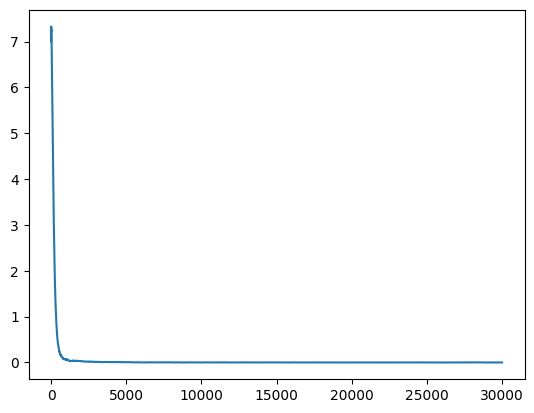

In [ ]:
import pandas as pd
pd.Series(losses).ewm(100).mean().plot();

added by josue: i want to see validation loss

In [ ]:
# ============================================================================
# VALIDATION LOSS EVALUATION
# ============================================================================
# This function samples batches from the dev set (not training set) to evaluate
# how well the model generalizes to unseen data. This helps us detect overfitting.
# ============================================================================

def get_dev_batch_pairs(n):
    """
    Sample n sentence pairs from the development/validation set.

    Args:
        n: Number of sentence pairs to sample (typically same as batch_size)

    Returns:
        xx: List of French sentences
        yy: List of Adja sentences (ground truth translations)
        src_lang: Source language code for NLLB tokenizer
        tgt_lang: Target language code for NLLB tokenizer
    """
    # Randomly sample n rows from dev_df without replacement
    batch = dev_df.sample(n=n)

    # Extract French and Adja sentences as lists
    xx = batch['French'].tolist()
    yy = batch['Translation'].tolist()

    # Set language codes (these tell NLLB's tokenizer which languages we're using)
    src_lang = 'fra_Latn'  # French in Latin script
    tgt_lang = 'adj_Latn'  # Adja in Latin script (check your actual code!)

    return xx, yy, src_lang, tgt_lang


# ============================================================================
# RUN VALIDATION EVALUATION
# ============================================================================
# After training, we want to check validation loss to see if the model is
# overfitting (memorizing training data) or generalizing well to new data.
# Low training loss + high validation loss = overfitting
# Low training loss + low validation loss = good generalization
# ============================================================================

model.eval()  # Put model in evaluation mode (disables dropout, etc.)
val_losses = []

with torch.no_grad():  # Don't compute gradients (saves memory, faster)
    # Sample 100 batches from dev set to get a reliable estimate of validation loss
    # 100 batches × batch_size gives us good coverage of the dev set
    for i in range(100):
        # Get a batch of French-Adja pairs from the dev set
        xx, yy, src_lang, tgt_lang = get_dev_batch_pairs(batch_size)

        # Set source language for tokenizer (tells it to expect French)
        tokenizer.src_lang = src_lang
        tokenizer.tgt_lang = tgt_lang

        # Tokenize French input sentences
        # This converts text → token IDs that the model can process
        x = tokenizer(xx, return_tensors='pt', padding=True, truncation=True,
                     max_length=max_length).to(model.device)

        # Tokenize Adja target sentences (ground truth translations)
        # as_target_tokenizer() ensures proper formatting for the decoder side
        with tokenizer.as_target_tokenizer():
            y = tokenizer(yy, return_tensors='pt', padding=True, truncation=True,
                         max_length=max_length).to(model.device)

        # Replace padding tokens with -100 so they're ignored in loss calculation
        # This prevents the model from being penalized for padding tokens
        y.input_ids[y.input_ids == tokenizer.pad_token_id] = -100

        # Forward pass: compute how well model predicts the Adja translation
        # Loss measures the difference between model's prediction and ground truth
        loss = model(**x, labels=y.input_ids).loss
        val_losses.append(loss.item())

# Print average validation loss across all 100 batches
print(f"Validation loss: {np.mean(val_losses):.4f}")

# Compare this to your final training loss (~0.019)
# If validation loss is much higher, you might be overfitting
# If they're close, your model is generalizing well!

model.train()  # Put model back in training mode if you want to continue training

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Validation loss: 5.7585


M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256205, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256205, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-1000...
  → Validation loss: 5.3257
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-2000...
  → Validation loss: 5.1575
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-3000...
  → Validation loss: 4.9939
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-4000...
  → Validation loss: 4.9450
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-5000...
  → Validation loss: 4.7894
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-6000...
  → Validation loss: 4.8100
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-7000...
  → Validation loss: 4.7801
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-8000...
  → Validation loss: 4.9763
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-9000...
  → Validation loss: 5.0231
Loading /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpo

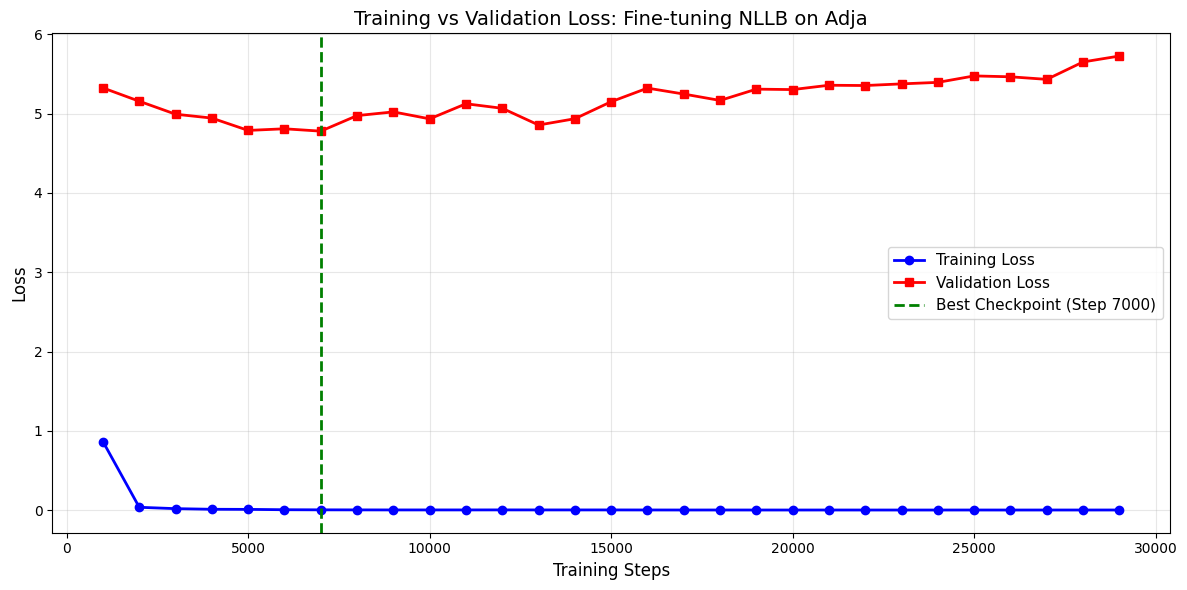


Plot saved to: /gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/training_validation_curves.png

For your LREC paper:
- Use checkpoint at step 7000 for BLEU evaluation
- Include this plot to show you properly handled overfitting
- Explain that validation loss guided checkpoint selection


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# EVALUATE VALIDATION LOSS FOR ALL CHECKPOINTS
# ============================================================================
# This evaluates EVERY saved checkpoint on the FULL dev set to find which
# checkpoint generalizes best (lowest validation loss).
# We'll then plot training vs validation loss to visualize overfitting.
# ============================================================================

def evaluate_checkpoint_on_full_dev(checkpoint_path, dev_df):
    """
    Load a checkpoint and compute validation loss on the ENTIRE dev set.

    Args:
        checkpoint_path: Path to saved model checkpoint
        dev_df: DataFrame containing dev set (French-Adja pairs)

    Returns:
        Average validation loss across all dev examples
    """
    # Load the checkpoint
    print(f"Loading {checkpoint_path}...")
    checkpoint_model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint_path)
    checkpoint_model.to(model.device)  # Move to GPU if available
    checkpoint_model.eval()  # Set to evaluation mode

    val_losses = []

    with torch.no_grad():  # Don't compute gradients (saves memory)
        # Go through ENTIRE dev set in batches
        for start_idx in range(0, len(dev_df), batch_size):
            end_idx = min(start_idx + batch_size, len(dev_df))
            batch = dev_df.iloc[start_idx:end_idx]

            # Get French and Adja sentences for this batch
            xx = batch['French'].tolist()
            yy = batch['Translation'].tolist()

            # Set up languages
            tokenizer.src_lang = 'fra_Latn'
            tokenizer.tgt_lang = 'adj_Latn'  # DOUBLE CHECK YOUR ACTUAL CODE!

            try:
                # Tokenize French input
                x = tokenizer(xx, return_tensors='pt', padding=True,
                            truncation=True, max_length=max_length).to(checkpoint_model.device)

                # Tokenize Adja target
                with tokenizer.as_target_tokenizer():
                    y = tokenizer(yy, return_tensors='pt', padding=True,
                                truncation=True, max_length=max_length).to(checkpoint_model.device)

                # Ignore padding tokens in loss calculation
                y.input_ids[y.input_ids == tokenizer.pad_token_id] = -100

                # Compute loss for this batch
                loss = checkpoint_model(**x, labels=y.input_ids).loss
                val_losses.append(loss.item())

            except RuntimeError as e:
                print(f"Error on batch {start_idx}-{end_idx}: {e}")
                continue

    # Return average loss across all dev batches
    avg_val_loss = np.mean(val_losses)
    print(f"  → Validation loss: {avg_val_loss:.4f}")

    # Clean up to free memory
    del checkpoint_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return avg_val_loss


# ============================================================================
# EVALUATE ALL CHECKPOINTS
# ============================================================================
# Loop through all saved checkpoints and compute their validation loss.
# This tells us which checkpoint generalizes best to unseen Adja sentences.
# ============================================================================

checkpoint_steps = list(range(1000, 30000, 1000))  # [1000, 2000, ..., 29000]
validation_losses = []

for step in checkpoint_steps:
    checkpoint_path = f"{MODEL_SAVE_PATH}/checkpoint-{step}"
    val_loss = evaluate_checkpoint_on_full_dev(checkpoint_path, dev_df)
    validation_losses.append(val_loss)

print("\n" + "="*60)
print("VALIDATION LOSS SUMMARY")
print("="*60)
for step, val_loss in zip(checkpoint_steps, validation_losses):
    print(f"Step {step:5d}: Val Loss = {val_loss:.4f}")

# Find the best checkpoint (lowest validation loss)
best_idx = np.argmin(validation_losses)
best_step = checkpoint_steps[best_idx]
best_val_loss = validation_losses[best_idx]
print("="*60)
print(f"BEST CHECKPOINT: Step {best_step} (Val Loss = {best_val_loss:.4f})")
print("="*60)


# ============================================================================
# PLOT TRAINING LOSS VS VALIDATION LOSS
# ============================================================================
# This visualization shows if/when overfitting occurs:
# - Training loss keeps dropping = model improving on training data
# - Validation loss increases = model getting worse on new data (overfitting!)
# - Gap between curves = degree of overfitting
# ============================================================================

# Extract training losses at checkpoint intervals (every 1000 steps)
train_losses_at_checkpoints = [np.mean(losses[i:i+1000]) for i in range(0, 29000, 1000)]

# Create the plot
plt.figure(figsize=(12, 6))

# Plot training loss
plt.plot(checkpoint_steps, train_losses_at_checkpoints,
         'b-o', label='Training Loss', linewidth=2, markersize=6)

# Plot validation loss
plt.plot(checkpoint_steps, validation_losses,
         'r-s', label='Validation Loss', linewidth=2, markersize=6)

# Mark the best checkpoint
plt.axvline(x=best_step, color='green', linestyle='--',
            label=f'Best Checkpoint (Step {best_step})', linewidth=2)

# Formatting
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss: Fine-tuning NLLB on Adja', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure for your paper!
plt.savefig(f'{MODEL_SAVE_PATH}/training_validation_curves.png', dpi=300)
plt.show()

print(f"\nPlot saved to: {MODEL_SAVE_PATH}/training_validation_curves.png")
print("\nFor your LREC paper:")
print(f"- Use checkpoint at step {best_step} for BLEU evaluation")
print(f"- Include this plot to show you properly handled overfitting")
print(f"- Explain that validation loss guided checkpoint selection")

In [ ]:
import torch

print("model class:", type(model).__name__)
print("tokenizer class:", type(tokenizer).__name__)

# where they came from (HF sets these when loading)
print("model.name_or_path:", getattr(model, "name_or_path", None))
print("config._name_or_path:", getattr(getattr(model, "config", None), "_name_or_path", None))
print("tokenizer.name_or_path:", getattr(tokenizer, "name_or_path", None))

# device / dtype
p = next(model.parameters())
print("device:", p.device, "dtype:", p.dtype)

# parameter count (just a sanity check)
print("num params (M):", sum(p.numel() for p in model.parameters())/1e6)


model class: M2M100ForConditionalGeneration
tokenizer class: NllbTokenizer
model.name_or_path: facebook/nllb-200-distilled-600M
config._name_or_path: facebook/nllb-200-distilled-600M
tokenizer.name_or_path: facebook/nllb-200-distilled-600M
device: cuda:0 dtype: torch.float32
num params (M): 615.072768


In [ ]:
def translate(text, src_lang='fra_Latn', tgt_lang='aj_Latn', a=16, b=1.5, max_input_length=1024, **kwargs):
    tokenizer.src_lang = src_lang
    tokenizer.tgt_lang = tgt_lang
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=max_input_length)
    result = model.generate(
        **inputs.to(model.device),
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
        max_new_tokens=int(a + b * inputs.input_ids.shape[1]),
        **kwargs
    )
    #print(inputs.input_ids.shape[1], result.shape[1])
    return tokenizer.batch_decode(result, skip_special_tokens=True)

In [ ]:
xx, yy, lang1, lang2 = get_batch_pairs(1, data=dev_df)
print(xx)
print(yy)
model.eval()
print(translate(xx[0], lang1, lang2, no_repeat_ngram_size=3, num_beams=5))

['vous ne parlez pas avec ma mère']
['mi xokɔ nuxu koɖo enɔnyɛ go']
['mi xokɔ nuxu koɖo enɔnyɛ go']


In [ ]:
!ls -alsh $MODEL_SAVE_PATH

total 917K
4.0K drwx------ 2 root root 4.0K Nov 20 06:19 checkpoint-1000
4.0K drwx------ 2 root root 4.0K Nov 20 07:20 checkpoint-10000
4.0K drwx------ 2 root root 4.0K Nov 20 07:27 checkpoint-11000
4.0K drwx------ 2 root root 4.0K Nov 20 07:33 checkpoint-12000
4.0K drwx------ 2 root root 4.0K Nov 20 07:40 checkpoint-13000
4.0K drwx------ 2 root root 4.0K Nov 20 07:47 checkpoint-14000
4.0K drwx------ 2 root root 4.0K Nov 20 07:54 checkpoint-15000
4.0K drwx------ 2 root root 4.0K Nov 20 08:00 checkpoint-16000
4.0K drwx------ 2 root root 4.0K Nov 20 08:07 checkpoint-17000
4.0K drwx------ 2 root root 4.0K Nov 20 08:14 checkpoint-18000
4.0K drwx------ 2 root root 4.0K Nov 20 08:21 checkpoint-19000
4.0K drwx------ 2 root root 4.0K Nov 20 06:26 checkpoint-2000
4.0K drwx------ 2 root root 4.0K Nov 20 08:28 checkpoint-20000
4.0K drwx------ 2 root root 4.0K Nov 20 08:34 checkpoint-21000
4.0K drwx------ 2 root root 4.0K Nov 20 08:41 checkpoint-22000
4.0K drwx------ 2 root root 4.0K Nov 20 08:48 

# 6. Using the model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import NllbTokenizer, AutoModelForSeq2SeqLM, AutoConfig
from tqdm.auto import tqdm, trange

In [ ]:
# trans_df = pd.read_csv('/gd/MyDrive/datasets/nlp/tyvan/for_translator.csv')
trans_df = pd.read_csv('/content/simple-dataset.csv')
trans_df.dropna(subset=['French', 'Translation'], inplace=True)

# trans_df.dropna(subset=['ru', 'tyv'], inplace=True)

# df_train, df_devtest = train_test_split(trans_df, test_size=1000, random_state=1)
# df_dev, df_test = train_test_split(df_devtest, test_size=0.5, random_state=1)


In [ ]:
# this code is adapted from  the Stopes repo of the NLLB team
# https://github.com/facebookresearch/stopes/blob/main/stopes/pipelines/monolingual/monolingual_line_processor.py#L214

import re
import sys
import typing as tp
import unicodedata
from sacremoses import MosesPunctNormalizer


mpn = MosesPunctNormalizer(lang="en")
mpn.substitutions = [
    (re.compile(r), sub) for r, sub in mpn.substitutions
]


def get_non_printing_char_replacer(replace_by: str = " ") -> tp.Callable[[str], str]:
    non_printable_map = {
        ord(c): replace_by
        for c in (chr(i) for i in range(sys.maxunicode + 1))
        # same as \p{C} in perl
        # see https://www.unicode.org/reports/tr44/#General_Category_Values
        if unicodedata.category(c) in {"C", "Cc", "Cf", "Cs", "Co", "Cn"}
    }

    def replace_non_printing_char(line) -> str:
        return line.translate(non_printable_map)

    return replace_non_printing_char

replace_nonprint = get_non_printing_char_replacer(" ")

def preproc(text):
    clean = mpn.normalize(text)
    clean = replace_nonprint(clean)
    # replace 𝓕𝔯𝔞𝔫𝔠𝔢𝔰𝔠𝔞 by Francesca
    clean = unicodedata.normalize("NFKC", clean)
    return clean

In [ ]:
# # def fix_tokenizer(tokenizer, new_lang='tyv_Cyrl'):
# #     """ Add a new language token to the tokenizer vocabulary (this should be done each time after its initialization) """
# #     old_len = len(tokenizer) - int(new_lang in tokenizer.added_tokens_encoder)
# #     tokenizer.lang_code_to_id[new_lang] = old_len-1
# #     tokenizer.id_to_lang_code[old_len-1] = new_lang
# #     # always move "mask" to the last position
# #     tokenizer.fairseq_tokens_to_ids["<mask>"] = len(tokenizer.sp_model) + len(tokenizer.lang_code_to_id) + tokenizer.fairseq_offset

# #     tokenizer.fairseq_tokens_to_ids.update(tokenizer.lang_code_to_id)
# #     tokenizer.fairseq_ids_to_tokens = {v: k for k, v in tokenizer.fairseq_tokens_to_ids.items()}
# #     if new_lang not in tokenizer._additional_special_tokens:
# #         tokenizer._additional_special_tokens.append(new_lang)
# #     # clear the added token encoder; otherwise a new token may end up there by mistake
# #     tokenizer.added_tokens_encoder = {}
# #     tokenizer.added_tokens_decoder = {}

# def fix_tokenizer(tokenizer, new_lang='aj_Latn'):
#     """
#     Safely add a new language token to the tokenizer vocabulary without breaking existing mappings.
#     """
#     if new_lang in tokenizer.lang_code_to_id:
#         print(f"{new_lang} already exists.")
#         return

#     new_id = max(tokenizer.lang_code_to_id.values()) + 1
#     tokenizer.lang_code_to_id[new_lang] = new_id
#     tokenizer.id_to_lang_code[new_id] = new_lang
#     tokenizer.fairseq_tokens_to_ids[new_lang] = new_id
#     tokenizer.fairseq_ids_to_tokens[new_id] = new_lang
#     if new_lang not in tokenizer._additional_special_tokens:
#         tokenizer._additional_special_tokens.append(new_lang)

#     tokenizer.added_tokens_encoder = {}
#     tokenizer.added_tokens_decoder = {}

#     print(f"Added {new_lang} with id {new_id}")

# def fix_tokenizer(tokenizer, new_lang='aj_Latn'): # aj = adja
#     """
#     Add a new language token to the tokenizer vocabulary
#     (this should be done each time after its initialization)
#     """
#     old_len = len(tokenizer) - int(new_lang in tokenizer.added_tokens_encoder)
#     tokenizer.lang_code_to_id[new_lang] = old_len-1
#     tokenizer.id_to_lang_code[old_len-1] = new_lang
#     # always move "mask" to the last position
#     tokenizer.fairseq_tokens_to_ids["<mask>"] = len(tokenizer.sp_model) + len(tokenizer.lang_code_to_id) + tokenizer.fairseq_offset

#     tokenizer.fairseq_tokens_to_ids.update(tokenizer.lang_code_to_id)
#     tokenizer.fairseq_ids_to_tokens = {v: k for k, v in tokenizer.fairseq_tokens_to_ids.items()}
#     if new_lang not in tokenizer._additional_special_tokens:
#         tokenizer._additional_special_tokens.append(new_lang)
#     # clear the added token encoder; otherwise a new token may end up there by mistake
#     tokenizer.added_tokens_encoder = {}
#     tokenizer.added_tokens_decoder = {}
def fix_tokenizer(tokenizer, new_lang="aj_Latn"):
    """
    Add a new language code token to the tokenizer in a version-safe way.
    Keeps the original function name so existing notebook calls don't change.
    """
    # 1) ensure the code exists as an additional special token
    extra = list(getattr(tokenizer, "additional_special_tokens", []))
    if new_lang not in extra:
        tokenizer.add_special_tokens({"additional_special_tokens": extra + [new_lang]})

    # 2) get its id
    new_id = tokenizer.convert_tokens_to_ids(new_lang)

    # 3) update mappings IF they exist in this version (no error if they don't)
    if hasattr(tokenizer, "lang_code_to_id") and isinstance(tokenizer.lang_code_to_id, dict):
        tokenizer.lang_code_to_id[new_lang] = new_id
    if hasattr(tokenizer, "id_to_lang_code") and isinstance(tokenizer.id_to_lang_code, dict):
        tokenizer.id_to_lang_code[new_id] = new_lang

    # Some versions stash these in init_kwargs too; update if present
    init = getattr(tokenizer, "init_kwargs", {})
    if isinstance(init.get("lang_code_to_id", None), dict):
        init["lang_code_to_id"][new_lang] = new_id
    if isinstance(init.get("id_to_lang_code", None), dict):
        init["id_to_lang_code"][str(new_id)] = new_lang

    # 4) (optional) keep a simple mirror map so later code can rely on it
    # even if this tokenizer version doesn't expose the old attrs
    if not hasattr(tokenizer, "_aj_lang_map"):
        tokenizer._aj_lang_map = {}
    tokenizer._aj_lang_map[new_lang] = new_id

    return new_id



In [ ]:
model_load_name = '/gd/MyDrive/models/simple-nllb-fr-aj-v2-from-ewe/checkpoint-3000'
model = AutoModelForSeq2SeqLM.from_pretrained(model_load_name).cuda()
tokenizer = NllbTokenizer.from_pretrained(model_load_name)
fix_tokenizer(tokenizer)


256204

In [ ]:
import torch

print("model class:", type(model).__name__)
print("tokenizer class:", type(tokenizer).__name__)

# where they came from (HF sets these when loading)
print("model.name_or_path:", getattr(model, "name_or_path", None))
print("config._name_or_path:", getattr(getattr(model, "config", None), "_name_or_path", None))
print("tokenizer.name_or_path:", getattr(tokenizer, "name_or_path", None))

# device / dtype
p = next(model.parameters())
print("device:", p.device, "dtype:", p.dtype)

# parameter count (just a sanity check)
print("num params (M):", sum(p.numel() for p in model.parameters())/1e6)


model class: M2M100ForConditionalGeneration
tokenizer class: NllbTokenizer
model.name_or_path: /gd/MyDrive/models/better-prepro-nllb-fr-aj-v2-from-ewe/checkpoint-3000
config._name_or_path: /gd/MyDrive/models/better-prepro-nllb-fr-aj-v2-from-ewe/checkpoint-3000
tokenizer.name_or_path: /gd/MyDrive/models/better-prepro-nllb-fr-aj-v2-from-ewe/checkpoint-3000
device: cuda:0 dtype: torch.float32
num params (M): 615.072768


In [ ]:
def translate(text, src_lang='fra_Latn', tgt_lang='aj_Latn', a=32, b=3, max_input_length=512, num_beams=4, **kwargs):
    tokenizer.src_lang = src_lang
    tokenizer.tgt_lang = tgt_lang
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=max_input_length)
    result = model.generate(
        **inputs.to(model.device),
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
        max_new_tokens=int(a + b * inputs.input_ids.shape[1]),
        num_beams=num_beams,
        **kwargs
    )
    return tokenizer.batch_decode(result, skip_special_tokens=True)

In [ ]:
# t = "мөңгүн үр чыткаш карарар"
# print(translate(t, 'tyv_Cyrl', 'rus_Cyrl'))
# # ['серебро от времени чернеет']

t = "Je vais à l'école."
print(translate(t, 'fra_Latn', 'aj_Latn'))


['Ŋuyi suklu']


In [ ]:
# translate(t, 'tyv_Cyrl', 'rus_Cyrl', do_sample=True, num_beams=1, temperature=1.5)
translate(t, 'fra_Latn', 'aj_Latn', do_sample=True, num_beams=1, temperature=1.5)


['Ŋ vayikɔ suklu']

In [ ]:
def batched_translate(texts, batch_size=16, **kwargs):
    """Translate texts in batches of similar length"""
    idxs, texts2 = zip(*sorted(enumerate(texts), key=lambda p: len(p[1]), reverse=True))
    results = []
    for i in trange(0, len(texts2), batch_size):
        results.extend(translate(texts2[i: i+batch_size], **kwargs))
    return [p for i, p in sorted(zip(idxs, results))]

In [ ]:
# rus_translated = batched_translate(df_dev.tyv, src_lang='tyv_Cyrl', tgt_lang='rus_Cyrl')
adja_translated = batched_translate(dev_df.French, src_lang='fra_Latn', tgt_lang='aj_Latn')


  0%|          | 0/27 [00:00<?, ?it/s]

In [ ]:
# df_dev['rus_translated'] = [translate(t, 'tyv_Cyrl', 'rus_Cyrl')[0] for t in tqdm(df_dev.tyv)]
# df_dev['tyv_translated'] = [translate(t, 'rus_Cyrl', 'tyv_Cyrl')[0] for t in tqdm(df_dev.ru)]

dev_df['adja_translated'] = [translate(t, 'fra_Latn', 'aj_Latn')[0] for t in tqdm(dev_df.French)]
dev_df['french_backtranslated'] = [translate(t, 'aj_Latn', 'fra_Latn')[0] for t in tqdm(dev_df.Translation)]


  0%|          | 0/425 [00:00<?, ?it/s]

  0%|          | 0/425 [00:00<?, ?it/s]

In [ ]:
!pip install sacrebleu

  Using cached sacrebleu-2.5.1-py3-none-any.whl.metadata (51 kB)
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
Using cached sacrebleu-2.5.1-py3-none-any.whl (104 kB)
Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)
Using cached portalocker-3.2.0-py3-none-any.whl (22 kB)


In [ ]:
import sacrebleu
bleu_calc = sacrebleu.BLEU()
chrf_calc = sacrebleu.CHRF(word_order=2)  # this metric is called ChrF++

In [ ]:
# this is just to test if sacreblue is installed
xx, yy = ['течёт холод'], ['несёт холодом']
print(bleu_calc.corpus_score(xx, [yy]))
print(chrf_calc.corpus_score(xx, [yy]))
print(chrf_calc.corpus_score(yy, [xx]))

BLEU = 0.00 0.0/0.0/0.0/0.0 (BP = 1.000 ratio = 1.000 hyp_len = 2 ref_len = 2)
chrF2++ = 36.75
chrF2++ = 42.30


In [ ]:
# print(bleu_calc.corpus_score(df_dev['rus_translated'].tolist(), [df_dev['ru'].tolist()]))
# print(chrf_calc.corpus_score(df_dev['rus_translated'].tolist(), [df_dev['ru'].tolist()]))
# print(bleu_calc.corpus_score(df_dev['tyv_translated'].tolist(), [df_dev['tyv'].tolist()]))
# print(chrf_calc.corpus_score(df_dev['tyv_translated'].tolist(), [df_dev['tyv'].tolist()]))

print(bleu_calc.corpus_score(dev_df['adja_translated'].tolist(), [dev_df['Translation'].tolist()]))
print(chrf_calc.corpus_score(dev_df['adja_translated'].tolist(), [dev_df['Translation'].tolist()]))

print(bleu_calc.corpus_score(dev_df['french_backtranslated'].tolist(), [dev_df['French'].tolist()]))
print(chrf_calc.corpus_score(dev_df['french_backtranslated'].tolist(), [dev_df['French'].tolist()]))


BLEU = 4.04 27.0/9.9/2.2/0.4 (BP = 1.000 ratio = 1.122 hyp_len = 2148 ref_len = 1915)
chrF2++ = 32.07
BLEU = 0.60 10.6/1.6/0.2/0.0 (BP = 1.000 ratio = 1.100 hyp_len = 2648 ref_len = 2408)
chrF2++ = 13.79


In [ ]:
pd.options.display.max_colwidth = 100

In [ ]:
# df_dev.sample(10, random_state=5)[['tyv', 'ru', 'tyv_translated', 'rus_translated']]
dev_df.sample(10, random_state=5)[['French', 'Translation', 'adja_translated', 'french_backtranslated']]


,French,Translation,adja_translated,french_backtranslated
2401,je montre le livre,ŋ dokɔasɛ wema lɔ,ŋ dádásɛ wemagbolɔ,lire aussi le livre de littérature
1907,elles donnent de l'argent,wo nana eho,wo nana eho,ils donnent eho
99,tu vois le chien,ɔ kpɔkpɔ avu,ɔkpɔ avu lɔ sá?,voir le chien
2436,vous montrez le cadeau,mi dokɔasɛ ajɔ lɔ,mi dokɔ ajɔ lɔ.,remportez aussi le prix.
3121,j'ai parlé adja,ŋ do ajagbe,ŋxokɔ nuxu do adashì,le jour du châtiment est proche.
2562,il ne cherche pas l'enfant,e jikɔ ɖevilɔ lɔ go,ɖe ji ɖevilɔ kpɔ gó.,Il prit le plus jeune enfant.
3430,elle va aimer mon ami,a lɔn anyi ‘xlɔ,Ava lɔn anyi xlɔ,il se jette à terre
4175,Qu'est-ce qu'il met dans la maison?,nyi e dakɔdo axwe lɔ mɛ?,Nyi esɔ dado axwemɛ ɔ?,Est-ce que tu l'as mis dans une chambre à coucher?
1777,Est-ce que je viens de l'école?,sukulu ŋu gbɔgbɔ so a?,Suklu yi ŋu gbɔ so à?,dans l'esprit scolaire?
33,vous mangez de la viande mi,ɖuɖuɔ elan,Miɖukɔ elan nɔŋu,repas en famille


In [ ]:
# print((df_dev.ru == df_dev.rus_translated).mean())
# print((df_dev.tyv == df_dev.tyv_translated).mean())
print((dev_df.Translation == dev_df.adja_translated).mean())
print((dev_df.French == dev_df.french_backtranslated).mean())


0.004705882352941176
0.0


In [ ]:
!pip install editdistance

In [ ]:
import editdistance

def ed_similarity(text1, text2):
    return max(0, 1 - editdistance.eval(text1, text2) / min(len(text1), len(text2)))

print(ed_similarity('кот', 'собака'))
print(ed_similarity('кот', 'кит'))

0
0.6666666666666667


In [ ]:
pd.Series([ed_similarity(row.French, row.french_backtranslated) for row in dev_df.itertuples()]).describe()

,0
count,425.000000
mean,0.093619
std,0.137913
min,0.000000
25%,0.000000
50%,0.000000
75%,0.142857
max,0.692308


In [ ]:
pd.Series([ed_similarity(row.Translation, row.adja_translated) for row in dev_df.itertuples()]).describe()

,0
count,425.000000
mean,0.368542
std,0.295491
min,0.000000
25%,0.058824
50%,0.363636
75%,0.619048
max,1.000000


In [ ]:
df_dev.index.name = "row_id"

NameError: name 'df_dev' is not defined

In [ ]:
df_dev.to_csv(model_load_name + "/dev_set_translated.tsv", sep="\t")

Evaluating another model (with extended vocabulary)

In [ ]:
model_load_name = '/gd/MyDrive/models/nllb-rus-tyv-v2-extvoc'

In [ ]:
cfg = AutoConfig.from_pretrained(model_load_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_load_name + "/pytorch_model_60k.bin", config=cfg).cuda()

In [ ]:
tokenizer = NllbTokenizer.from_pretrained(model_load_name)
fix_tokenizer(tokenizer)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
df_dev['rus_translated2'] = [translate(t, 'tyv_Cyrl', 'rus_Cyrl')[0] for t in tqdm(df_dev.tyv)]

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
df_dev['tyv_translated2'] = [translate(t, 'rus_Cyrl', 'tyv_Cyrl')[0] for t in tqdm(df_dev.ru)]

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
print(bleu_calc.corpus_score(df_dev['rus_translated2'].tolist(), [df_dev['ru'].tolist()]))
print(chrf_calc.corpus_score(df_dev['rus_translated2'].tolist(), [df_dev['ru'].tolist()]))
print(bleu_calc.corpus_score(df_dev['tyv_translated2'].tolist(), [df_dev['tyv'].tolist()]))
print(chrf_calc.corpus_score(df_dev['tyv_translated2'].tolist(), [df_dev['tyv'].tolist()]))

BLEU = 25.18 52.4/31.3/20.4/13.3 (BP = 0.976 ratio = 0.976 hyp_len = 2269 ref_len = 2324)
chrF2++ = 49.85
BLEU = 23.22 51.6/29.4/18.3/11.6 (BP = 0.975 ratio = 0.975 hyp_len = 2312 ref_len = 2371)
chrF2++ = 49.87


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_load_name).cuda()

In [ ]:
df_dev['rus_translated3'] = [translate(t, 'tyv_Cyrl', 'rus_Cyrl')[0] for t in tqdm(df_dev.tyv)]
df_dev['tyv_translated3'] = [translate(t, 'rus_Cyrl', 'tyv_Cyrl')[0] for t in tqdm(df_dev.ru)]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
print(bleu_calc.corpus_score(df_dev['rus_translated3'].tolist(), [df_dev['ru'].tolist()]))
print(chrf_calc.corpus_score(df_dev['rus_translated3'].tolist(), [df_dev['ru'].tolist()]))
print(bleu_calc.corpus_score(df_dev['tyv_translated3'].tolist(), [df_dev['tyv'].tolist()]))
print(chrf_calc.corpus_score(df_dev['tyv_translated3'].tolist(), [df_dev['tyv'].tolist()]))

BLEU = 23.06 51.1/29.1/18.1/11.5 (BP = 0.978 ratio = 0.978 hyp_len = 2273 ref_len = 2324)
chrF2++ = 48.56
BLEU = 26.12 53.4/32.5/21.0/13.6 (BP = 0.985 ratio = 0.985 hyp_len = 2336 ref_len = 2371)
chrF2++ = 52.60


In [ ]:
df_dev['rus2eng'] = [translate(t, 'tyv_Cyrl', 'eng_Latn')[0] for t in tqdm(df_dev.tyv)]
df_dev['tyv2eng'] = [translate(t, 'rus_Cyrl', 'eng_Latn')[0] for t in tqdm(df_dev.ru)]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Results with num_beams=1:
```
V1
BLEU = 23.21 51.2/29.1/18.0/11.8 (BP = 0.978 ratio = 0.978 hyp_len = 2273 ref_len = 2324)
chrF2++ = 47.88
BLEU = 22.03 51.5/29.7/17.9/10.4 (BP = 0.952 ratio = 0.953 hyp_len = 2260 ref_len = 2371)
chrF2++ = 49.37
V2
BLEU = 24.08 50.9/29.5/19.1/12.3 (BP = 0.988 ratio = 0.988 hyp_len = 2297 ref_len = 2324)
chrF2++ = 48.96
BLEU = 22.50 50.5/28.5/17.7/11.1 (BP = 0.974 ratio = 0.974 hyp_len = 2310 ref_len = 2371)
chrF2++ = 48.85
V3
BLEU = 22.25 49.8/27.8/17.2/11.0 (BP = 0.983 ratio = 0.983 hyp_len = 2284 ref_len = 2324)
chrF2++ = 47.89
BLEU = 25.28 52.2/31.2/20.0/13.1 (BP = 0.989 ratio = 0.989 hyp_len = 2346 ref_len = 2371)
chrF2++ = 51.87
````

Results with 4 beams:
```
V1
BLEU = 24.14 52.5/30.4/18.9/12.1 (BP = 0.981 ratio = 0.981 hyp_len = 2281 ref_len = 2324)
chrF2++ = 49.49
BLEU = 23.41 52.1/31.0/18.9/11.3 (BP = 0.966 ratio = 0.967 hyp_len = 2292 ref_len = 2371)
chrF2++ = 50.89
V2
BLEU = 25.18 52.4/31.3/20.4/13.3 (BP = 0.976 ratio = 0.976 hyp_len = 2269 ref_len = 2324)
chrF2++ = 49.85
BLEU = 23.22 51.6/29.4/18.3/11.6 (BP = 0.975 ratio = 0.975 hyp_len = 2312 ref_len = 2371)
chrF2++ = 49.87
V3
BLEU = 23.06 51.1/29.1/18.1/11.5 (BP = 0.978 ratio = 0.978 hyp_len = 2273 ref_len = 2324)
chrF2++ = 48.56
BLEU = 26.12 53.4/32.5/21.0/13.6 (BP = 0.985 ratio = 0.985 hyp_len = 2336 ref_len = 2371)
chrF2++ = 52.60
```

Which means:
* For all directions and models, beam search improves the results
* Longer training builds up quality for Tyvan, but decreases it for Russian.

```
                                  | tyv->rus | rus->tyv
Model v1 (no vocabulary update):  |
    no beam search                |   23.21  |  22.03
    num_beams = 4                 |   24.14  |  23.41
Model v2 (with vocabulary update):|
    no beam search                |   24.08  |  22.50
    num_beams = 4                 |   25.18  |  23.22
```

In [ ]:
df_dev.to_csv(model_load_name + "/dev_set_translated.tsv", sep="\t")

Here are some examples of how translation has changed:

In [ ]:
df_dev.sample(5, random_state=1)[['tyv', 'ru', 'rus_translated']]

,tyv,ru,rus_translated
row_id,,,
5442,транспорт херекселдерин ажыглаарының база шимчээшкинниң айыыл чок чоруунуң дүрүмнери,правила безопасности движения и эксплуатации транспортных средств,правила безопасности движения и эксплуатации транспортных средств
57777,аъш-чем садыы,продовольственный магазин,продовольственный магазин
104130,"Бүгү чүве төнген, бойлаан.","Все было кончено, потеряно.","Все было кончено, самостоятельно."
49344,фокуска кирбес,не попасть в фокус,не попасть в фокус
28319,рекорд тургузар,установить рекорд,поставить рекорд


In [ ]:
df_dev.sample(20, random_state=1)[[
    'tyv', 'tyv_translated', 'tyv_translated2', 'tyv_translated3', 'tyv2eng',
    'ru', 'rus_translated', 'rus_translated2', 'rus_translated3', 'rus2eng',
]]

,tyv,tyv_translated,tyv_translated2,tyv_translated3,tyv2eng,ru,rus_translated,rus_translated2,rus_translated3,rus2eng
row_id,,,,,,,,,,
5442,транспорт херекселдерин ажыглаарының база шимчээшкинниң айыыл чок чоруунуң дүрүмнери,шимчээшкинниң болгаш транспорт аймаан ажыглаарының айыыл чок чоруунуң дүрүмнери,транспорт аймаан шимчээшкининиң болгаш ажыглаарының айыыл чок чоруунуң дүрүмнери,транспорт аймаан шимчээшкининиң болгаш транспорт аймаан ажыглаарының айыыл чок чоруунуң дүрүмнери,ң болгаш транспорт аймаан ажыглаарының айыыл чок чоруунуң дүрүмнери,правила безопасности движения и эксплуатации транспортных средств,правила безопасности движения и эксплуатации транспортных средств,правила эксплуатации транспортных средств и безопасности движения,правила безопасности эксплуатации транспортных средств и движения,дүрүмнер транспорт херекселдерин ажыглаарының болгаш шимчээшкинниң айыыл чок чоруунуң дугайында
57777,аъш-чем садыы,аъш-чем садыы,аъш-чем садыы,аъш-чем садыы,садыы,продовольственный магазин,продовольственный магазин,продовольственный магазин,продовольственный магазин,садыы
104130,"Бүгү чүве төнген, бойлаан.","Шупту чүве доозулган, читкен.","Шупту чүве төнген, читкен.","Бүгү чүве бойлаан, читкен.","-даа, читкен-даа.","Все было кончено, потеряно.","Все было кончено, самостоятельно.","Все кончилось, разошёлся.","Все кончено, кончено.","-ла, бүгү чүве кончилось."
49344,фокуска кирбес,илби-шидиге алзыр арга чок,илбиге алыспас,илби-шидиге туттурбас,гге күш четпес,не попасть в фокус,не попасть в фокус,не попасться в фокусы,не попасть на фокус,г
28319,рекорд тургузар,рекорд тургузар,рекорд тургузар,рекорд тургузар,г тургузар,установить рекорд,поставить рекорд,установить рекорд,установить рекорд,г тургузар
43534,чурукту делгээр,чурукту делгээр,чурук делгээр,чурукту делгээр,ң чурукту делгээр,выставлять картину,выставлять картину,развернуть картину,экспонировать картину,чурукту делгередип чуруур
37159,ылап хөделир,ылап хөделир,бүзүрелдиг хөделир,ылап хөделир,г хөделир,действовать наверняка,действовать аккуратно,действовать наверняка,действовать наверняка,г хөделир
36993,колдуктап алгаш чоруур,шыңганның адаанга көдүрүп алгаш чоруур,колдук адаанга аппаар,колдуктап алгаш чоруур,г шыгжаар,нести под мышкой,нести под мышками,носить под мышкой,нести под мышкой,алгаш чоруур
116009,Копривничко-Крижевачка,Копривничко-Крижевачка,Копривничко-Крижевачка,Копривничко-Крижевачка,чко-Крижевачка,Копривничко-Крижевачка,Копривничко-Крижевачка,Копривничко-Крижевачка,Копривничко-Крижевачка,вничко-Крижевачка


In [ ]:
cols = ['ind', 'tyv', 'ru']
splits = {'train': df_train[df_train.index<=49_454], 'test': df_test, 'dev': df_dev}
df_joint = []
for k, v in splits.items():
    v = v[cols].copy()
    v.index.name = "row_id"
    v['split'] = k
    df_joint.append(v)
df_joint = pd.concat(df_joint)
df_joint.shape

(50000, 4)

In [ ]:
df_joint.sample(5)

,ind,tyv,ru,split
row_id,,,,
314,328,Өг-бүле бүрүзү эвээш дээрге-ле 500-600 ивини азырап өстүрзүн.,Пусть на каждую семью было хотя бы по 500-600 оленей.,train
4376,4390,Өрээл аяннаны берген,Комната приняла хороший вид,train
13377,13392,кым-бир кижи-биле силер деп чугаалажыр,быть на вы с кем-либо,train
91144,97279,"Идээледир чемнениринде база эки чүү-даа чүве чок, ынчангаш арай эвээшти чиңер.","Ничего хорошего нет и в переедании, так что ешьте поменьше.",dev
307,321,"Оларның аразында 14 суурда 500 четпес, а 8 суурда 250 хире чурттакчы бар.","Среди них в 14 селах менее 500, в восьми - менее 250 человек.",train


In [ ]:
df_joint.to_csv("/gd/MyDrive/datasets/nlp/tyvan/rus_tyv_parallel_50k.tsv", sep="\t")

# Publishing the model to HF

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|
    
    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Token: 
Add token as git credential? (Y/n) Y
Token is valid (permission: write).
Your token has been saved in your

In [ ]:
from transformers import NllbTokenizer, AutoModelForSeq2SeqLM, AutoConfig

In [ ]:
def fix_tokenizer(tokenizer, new_lang='tyv_Cyrl'):
    """ Add a new language token to the tokenizer vocabulary (this should be done each time after its initialization) """
    old_len = len(tokenizer) - int(new_lang in tokenizer.added_tokens_encoder)
    tokenizer.lang_code_to_id[new_lang] = old_len-1
    tokenizer.id_to_lang_code[old_len-1] = new_lang
    # always move "mask" to the last position
    tokenizer.fairseq_tokens_to_ids["<mask>"] = len(tokenizer.sp_model) + len(tokenizer.lang_code_to_id) + tokenizer.fairseq_offset

    tokenizer.fairseq_tokens_to_ids.update(tokenizer.lang_code_to_id)
    tokenizer.fairseq_ids_to_tokens = {v: k for k, v in tokenizer.fairseq_tokens_to_ids.items()}
    if new_lang not in tokenizer._additional_special_tokens:
        tokenizer._additional_special_tokens.append(new_lang)
    # clear the added token encoder; otherwise a new token may end up there by mistake
    tokenizer.added_tokens_encoder = {}
    tokenizer.added_tokens_decoder = {}

In [ ]:
model_load_name = '/gd/MyDrive/models/nllb-rus-tyv-v1'
model = AutoModelForSeq2SeqLM.from_pretrained(model_load_name)
tokenizer = NllbTokenizer.from_pretrained(model_load_name)
fix_tokenizer(tokenizer)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
upload_repo = "slone/nllb-rus-tyv-v1"
tokenizer.push_to_hub(upload_repo)
model.push_to_hub(upload_repo)

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/slone/nllb-rus-tyv-v1/commit/e45e25aa62c8487aaa7050d804f9851ae01e353a', commit_message='Upload M2M100ForConditionalGeneration', commit_description='', oid='e45e25aa62c8487aaa7050d804f9851ae01e353a', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
model_load_name = '/gd/MyDrive/models/nllb-rus-tyv-v2-extvoc'
tokenizer = NllbTokenizer.from_pretrained(model_load_name)
cfg = AutoConfig.from_pretrained(model_load_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_load_name + "/pytorch_model_60k.bin", config=cfg)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
upload_repo = "slone/nllb-rus-tyv-v2-extvoc"
tokenizer.push_to_hub(upload_repo)
model.push_to_hub(upload_repo)

sentencepiece.bpe.model:   0%|          | 0.00/5.14M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.51G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/slone/nllb-rus-tyv-v2-extvoc/commit/48e9b1269b037fe08280bfec990c189e5748bccd', commit_message='Upload M2M100ForConditionalGeneration', commit_description='', oid='48e9b1269b037fe08280bfec990c189e5748bccd', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
print(tokenizer.convert_ids_to_tokens([256202, 256203, 256204])) # ['zul_Latn', 'tyv_Cyrl', '<mask>']
print(tokenizer.convert_tokens_to_ids(['zul_Latn', 'tyv_Cyrl', '<mask>'])) # [256202, 256203, 256204]
# this is consistent now, wow!

['zul_Latn', '<mask>', 'tyv_Cyrl']
[256202, 256204, 256203]


Testing that it works

In [ ]:
MODEL_URL = 'slone/nllb-rus-tyv-v1'
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_URL)
tokenizer = NllbTokenizer.from_pretrained(MODEL_URL, force_download=True)
fix_tokenizer(tokenizer)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
def translate(
    text,
    model,
    tokenizer,
    src_lang='rus_Cyrl',
    tgt_lang='tyv_Cyrl',
    max_length='auto',
    num_beams=4,
    no_repeat_ngram_size=4,
    n_out=None,
    **kwargs
):
    tokenizer.src_lang = src_lang
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    if max_length == 'auto':
        max_length = int(32 + 2.0 * encoded.input_ids.shape[1])
    model.eval()
    generated_tokens = model.generate(
        **encoded.to(model.device),
        forced_bos_token_id=tokenizer.lang_code_to_id[tgt_lang],
        max_length=max_length,
        num_beams=num_beams,
        no_repeat_ngram_size=no_repeat_ngram_size,
        num_return_sequences=n_out or 1,
        **kwargs
    )
    out = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
    if isinstance(text, str) and n_out is None:
        return out[0]
    return out

In [ ]:
translate("красная птица", model=model, tokenizer=tokenizer)

'кызыл куш'

In [ ]:
translate("красная птица", model=model, tokenizer=tokenizer, tgt_lang='eng_Latn')

': кызыл куш'

In [ ]:
lang_to_code = {
    'Русский | Russian': 'rus_Cyrl',
    'Тувинский | Tyvan': 'tyv_Cyrl',
}

In [ ]:
def translate_wrapper(text, src, trg, correct=None):
    src_lang = lang_to_code.get(src)
    tgt_lang = lang_to_code.get(trg)
    if src == trg:
        return 'Please choose two different languages'
    print(text, src, trg)
    result = translate(
        text=text,
        model=model,
        tokenizer=tokenizer,
        src_lang=src_lang,
        tgt_lang=tgt_lang,
    )
    return result

In [ ]:
translate_wrapper("красная птица", 'Русский | Russian', 'Тувинский | Tyvan')

красная птица Русский | Russian Тувинский | Tyvan


'кызыл куш'